**Step 1: Understand Pandas mindset first**  
Pandas is built around 2 core objects:

Series = one column  
DataFrame = full table (rows + columns)  
Think of Pandas as:

SQL + Excel + Python combined  
Best for cleaning, transforming, summarizing tabular data

**Step 2: Load data correctly**   
read_csv, read_excel, read_sql, etc.  

Key theory:  
Loading is not just import; it defines your entire pipeline quality.  
Wrong dtypes at loading stage cause bugs later.

In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
# print first 7 rows
df.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


In [4]:
# number of rows and columns
df.shape

(891, 12)

In [5]:
# column names in list form
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [6]:
# numeric columns in list form
df.select_dtypes(include=['int64', 'float64']).columns.tolist()

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

**Step 3: Quick inspection (EDA starter)**

In [7]:
# quick info about dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# quick stats for numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
df.sample(5, random_state=42)
# here random_state is used to make sure we get the same random sample every time we run the code.
# random_state = 42 is a common choice for a random seed, but you can use any integer value.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


**Step 4: Selecting data ([], loc, iloc)**   
This is one of the most important topics

In [11]:
# select a column
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [12]:
# loc is label based, means you have to specify the name of the row and column that you want to select.
df.loc[0, 'Age']  # select the value in the first row and 'Age' column

np.float64(22.0)

In [13]:
# iloc is integer position based, means you have to specify the integer index of the row and column that you want to select.
df.iloc[0, 3]  # select the value in the first row and fourth column

'Braund, Mr. Owen Harris'

In [14]:
# Get first 5 rows using loc
df.loc[0:4, 'PassengerId':'Age']  # using loc

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0


In [15]:
# Get first 5 rows using iloc
df.iloc[0:5, 0:4]  # using iloc

,PassengerId,Survived,Pclass,Name
0,1,0,3,"Braund, Mr. Owen Harris"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,1,3,"Heikkinen, Miss. Laina"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,5,0,3,"Allen, Mr. William Henry"


**Step 5: Filtering like a professional**  
Filtering is how analysts ask questions from data.

In [16]:
# example
df[(df["Age"] > 30) & (df["Fare"] > 50)] # select rows where age is greater than 30 and fare is greater than 50

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
35,36,0,1,"Holverson, Mr. Alexander Oskar",male,42.0,1,0,113789,52.0000,NaN,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S


In [17]:
# Filter passengers with Age > 30.
df[df["Age"] > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [18]:
# Filter Sex == "female" and Pclass == 1.
df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0,0,17466,25.9292,D17,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C


In [19]:
# Filter rows where Embarked is C or S.
df[df['Embarked'].isin(['C', 'S'])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [20]:
# Filter rows where Age is missing.
df[df['Age'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [21]:
# Count how many passengers have Fare > 100.
(df['Fare'] > 100).sum()

np.int64(53)

**Step 6: Numerical vs Categorical analysis**  
Numerical (Age, Fare): mean, median, std, skew  
Categorical (Sex, Embarked): mode, frequency, proportion  

Sample Decision logic:  
If numerical data is skewed/outlier-heavy -> median is safer than mean.

In [22]:
# for Age column, compute mean, median, std, skew
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_std = df['Age'].std()
age_skew = df['Age'].skew()
print(f"Age - Mean: {age_mean}, Median: {age_median}, Std: {age_std}, Skew: {age_skew}")

Age - Mean: 29.69911764705882, Median: 28.0, Std: 14.526497332334042, Skew: 0.38910778230082704


In [23]:
# for Sex column, compute frequency, proportion
sex_freq = df['Sex'].value_counts()
sex_prop = df['Sex'].value_counts(normalize=True)
print(f"Sex - Frequency: {sex_freq}, Proportion: {sex_prop}")

Sex - Frequency: Sex
male      577
female    314
Name: count, dtype: int64, Proportion: Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


In [24]:
# Is Age closer to normal or skewed?
if age_skew < 0:
    print("Age is left-skewed.")
elif age_skew > 0:
    print("Age is right-skewed.")
else:
    print("Age is approximately normal.")

Age is right-skewed.


**Step 7: Missing value handling (very important for ML)**  
Missing values can break ML models.  
Strategies: drop, fill with mean/median/mode, or use advanced imputation.


In [25]:
# check how many missing values in each column
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Methods for filling missing values:
- Numeric normal: fill with mean or median
- Numeric skewed: fill with median
- Categorical: fill with mode

In [26]:
# fill age missing values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [27]:
# fill Embarked missing values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [28]:
# percentage of missing values in Cabin column
df['Cabin'].isnull().sum() / len(df) * 100

np.float64(77.10437710437711)

Decide what to do with Cabin and justify in 2 lines: 
Since Cabin has a very high percentage of missing values (77%), it is best to drop this column as it may not provide useful information for analysis or modeling. Retaining it could introduce bias or noise due to the large amount of missing data.

**Step 8: GroupBy and aggregation**  
Practical use:
- average fare by class
- survival rate by sex
- age stats by sex + class

In [29]:
# compute average fare by class
avg_fare_by_class = df.groupby('Pclass')['Fare'].mean()
print(avg_fare_by_class)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [30]:
# Compute average Age by Sex
avg_age_by_sex = df.groupby('Sex')['Age'].mean()
print(avg_age_by_sex)

Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64


**Step 9: Sorting, ranking, and top/bottom analysis**


In [32]:
# top 10 highest fares
top_10_fares = df.nlargest(10, 'Fare')
print(top_10_fares[['PassengerId', 'Fare']])

     PassengerId      Fare
258          259  512.3292
679          680  512.3292
737          738  512.3292
27            28  263.0000
88            89  263.0000
341          342  263.0000
438          439  263.0000
311          312  262.3750
742          743  262.3750
118          119  247.5208


In [33]:
# Bottom 10 ages (non-null only)
bottom_10_ages = df.nsmallest(10, 'Age')
print(bottom_10_ages[['PassengerId', 'Age']])

     PassengerId   Age
803          804  0.42
755          756  0.67
469          470  0.75
644          645  0.75
78            79  0.83
831          832  0.83
305          306  0.92
164          165  1.00
172          173  1.00
183          184  1.00


In [34]:
# Sort by Sex then Age
sorted_df = df.sort_values(by=['Sex', 'Age'])
print(sorted_df[['PassengerId', 'Sex', 'Age']])

     PassengerId     Sex    Age
469          470  female   0.75
644          645  female   0.75
172          173  female   1.00
381          382  female   1.00
119          120  female   2.00
..           ...     ...    ...
116          117    male  70.50
96            97    male  71.00
493          494    male  71.00
851          852    male  74.00
630          631    male  80.00

[891 rows x 3 columns]


**Step 10: Basic visualization for EDA**  
Visuals help you validate patterns quickly:  
- Histogram -> distribution
- Boxplot -> outliers
- Countplot -> category frequency
- Heatmap -> correlation

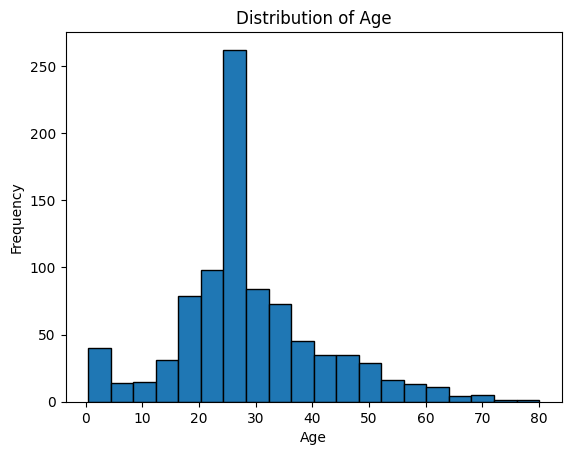

In [37]:
# plot histogram of Age
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

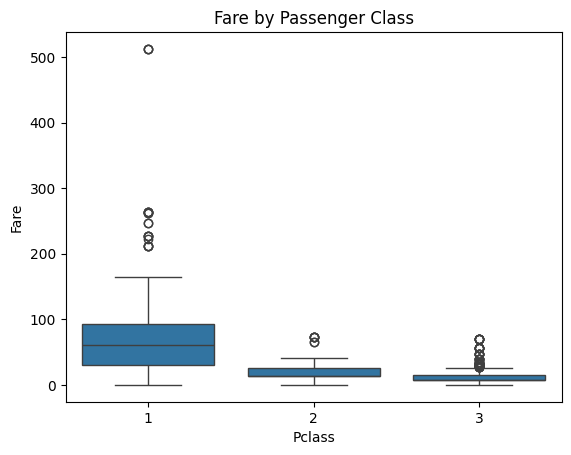

In [38]:
# boxplot of Fare by Pclass
import seaborn as sns
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare by Passenger Class')
plt.show()

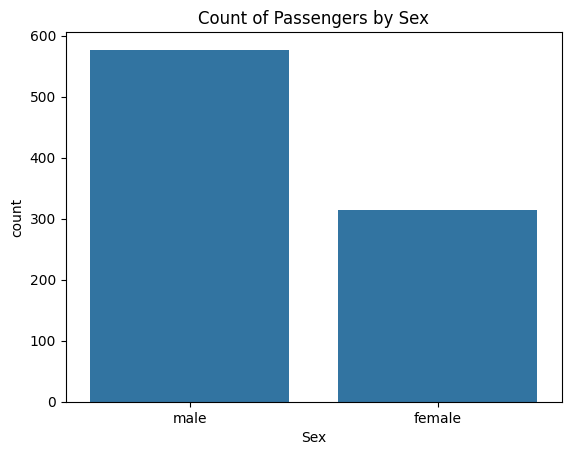

In [39]:
# Plot countplot of Sex
sns.countplot(x='Sex', data=df)
plt.title('Count of Passengers by Sex')
plt.show()

In [40]:
# Make crosstab of Sex vs Survived
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


**Step 11: Pipeline thinking (real project style)**  
Typical pipeline:  
- Load
- Inspect
- Clean
- Transform
- Analyze/group
- Visualize
- Export